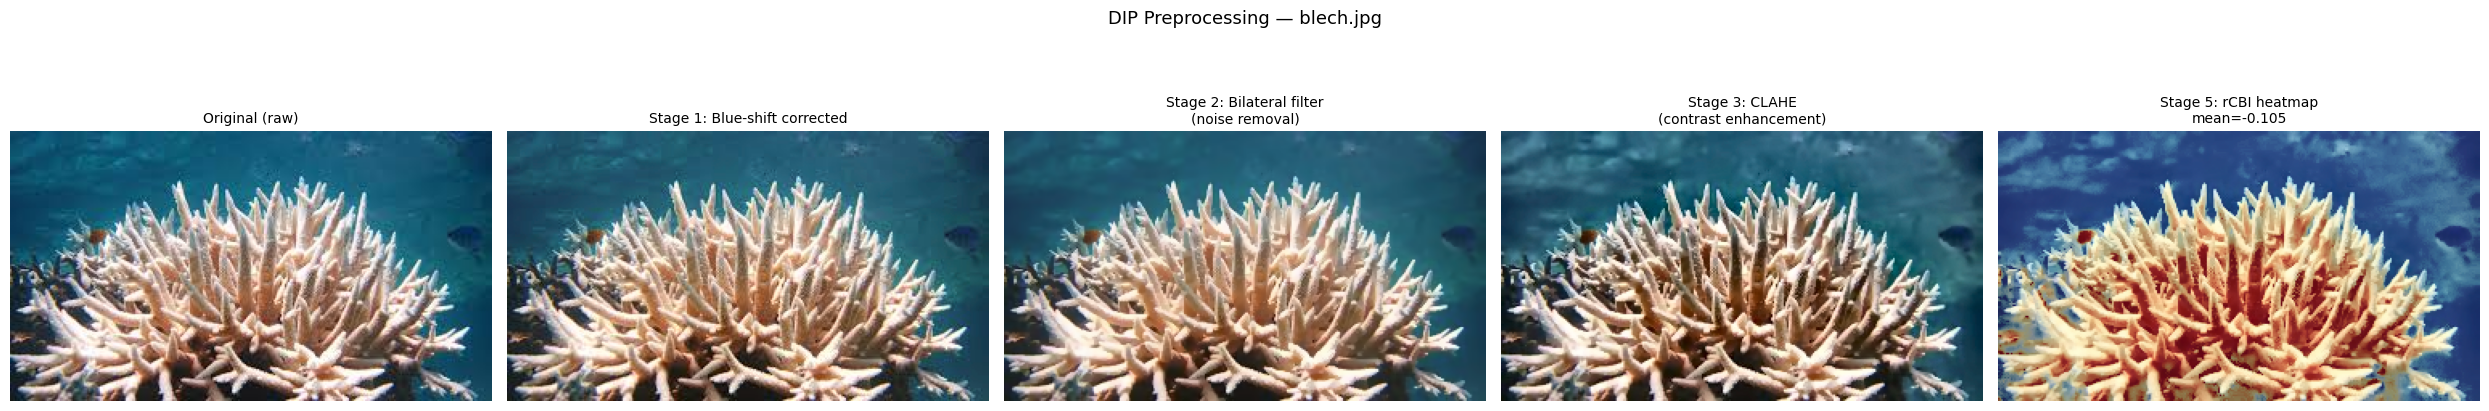

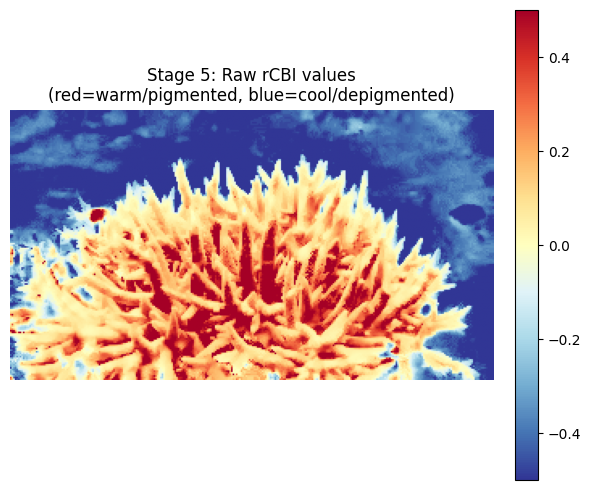


Image size: (168, 300, 3)

GLCM Texture Features (Stage 4):
  glcm_contrast: 84.7085
  glcm_correlation: 0.8229
  glcm_energy: 0.0635
  glcm_homogeneity: 0.3992

rCBI mean (Stage 5): -0.1046


In [5]:
"""
test_preprocessing_notebook.py
Paste into a Jupyter notebook cell.
Change IMAGE_PATH to any coral image you want to test.
"""

%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

# ── Point to wherever preprocessing.py lives ─────────────────────────────────
   # <-- change this
from preprocessor import (
    correct_blue_shift,
    apply_bilateral_filter,
    apply_clahe,
    extract_glcm_features,
    generate_rcbi_heatmap,
)

# ── Change to any image you want to test ──────────────────────────────────────
IMAGE_PATH = "blech.jpg"   # <-- change this


# ── Helper ────────────────────────────────────────────────────────────────────
def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# ── Run all stages in order ───────────────────────────────────────────────────
img_bgr   = cv2.imread(IMAGE_PATH)
assert img_bgr is not None, f"Could not load: {IMAGE_PATH}"

corrected         = correct_blue_shift(img_bgr)       # Stage 1
denoised          = apply_bilateral_filter(corrected)  # Stage 2
clean_bgr         = apply_clahe(denoised)              # Stage 3
glcm              = extract_glcm_features(clean_bgr)   # Stage 4
rcbi_map, heatmap = generate_rcbi_heatmap(clean_bgr)   # Stage 5
rcbi_mean         = float(rcbi_map.mean())


# ── Display — one panel per stage ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle(
    f"DIP Preprocessing — {IMAGE_PATH.split('/')[-1]}",
    fontsize=13
)

panels = [
    (bgr_to_rgb(img_bgr),   "Original (raw)"),
    (bgr_to_rgb(corrected), "Stage 1: Blue-shift corrected"),
    (bgr_to_rgb(denoised),  "Stage 2: Bilateral filter\n(noise removal)"),
    (bgr_to_rgb(clean_bgr), "Stage 3: CLAHE\n(contrast enhancement)"),
    (bgr_to_rgb(heatmap),   f"Stage 5: rCBI heatmap\nmean={rcbi_mean:.3f}"),
]

for ax, (img, title) in zip(axes, panels):
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


# ── Also show the raw rCBI map separately with colorbar ──────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 5))
im = ax2.imshow(rcbi_map, cmap="RdYlBu_r", vmin=-0.5, vmax=0.5)
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
ax2.set_title("Stage 5: Raw rCBI values\n(red=warm/pigmented, blue=cool/depigmented)")
ax2.axis("off")
plt.tight_layout()
plt.show()


# ── Print feature values ──────────────────────────────────────────────────────
print(f"\nImage size: {img_bgr.shape}")
print("\nGLCM Texture Features (Stage 4):")
for k, v in glcm.items():
    print(f"  {k}: {v:.4f}")
print(f"\nrCBI mean (Stage 5): {rcbi_mean:.4f}")


# ── Optional: cv2.imshow popup ────────────────────────────────────────────────
# Works in VS Code Jupyter. May crash browser-based Jupyter.

# cv2.imshow("Original",         img_bgr)
# cv2.imshow("Blue corrected",   corrected)
# cv2.imshow("Bilateral filter", denoised)
# cv2.imshow("CLAHE",            clean_bgr)
# cv2.imshow("rCBI heatmap",     heatmap)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [ ]:
# ── Create output directory ────────────────────────────────────────────────
import os
OUTPUT_DIR = "outputs/preprocessing"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Extract filename (without extension) ───────────────────────────────────
filename = os.path.splitext(os.path.basename(IMAGE_PATH))[0]

# ── Save images ────────────────────────────────────────────────────────────
cv2.imwrite(f"{OUTPUT_DIR}/{filename}_original.jpg", img_bgr)
cv2.imwrite(f"{OUTPUT_DIR}/{filename}_corrected.jpg", corrected)
cv2.imwrite(f"{OUTPUT_DIR}/{filename}_denoised.jpg", denoised)
cv2.imwrite(f"{OUTPUT_DIR}/{filename}_clahe.jpg", clean_bgr)
cv2.imwrite(f"{OUTPUT_DIR}/{filename}_heatmap.jpg", heatmap)

# ── Save rCBI raw map (normalized for visibility) ──────────────────────────
rcbi_norm = cv2.normalize(rcbi_map, None, 0, 255, cv2.NORM_MINMAX)
rcbi_norm = rcbi_norm.astype(np.uint8)
cv2.imwrite(f"{OUTPUT_DIR}/{filename}_rcbi_raw.jpg", rcbi_norm)

print(f"\nSaved all outputs to: {OUTPUT_DIR}")